In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('games_metadata.csv')

# is_free

Number of missing (NaN) values in 'is_free': 0.00%


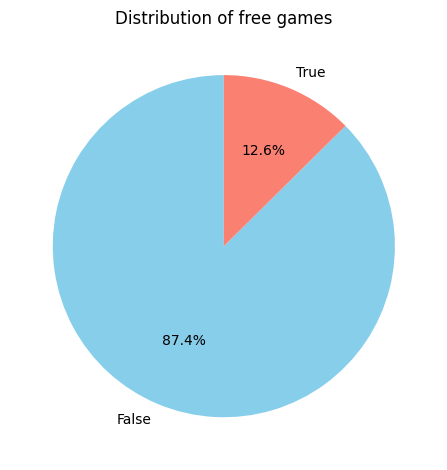

In [2]:
na_count = df["is_free"].isna().mean() * 100
print(f"Number of missing (NaN) values in 'is_free': {na_count:.2f}%")

counts = df["is_free"].value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title(f'Distribution of free games')
plt.ylabel('')  # Hide y-label
plt.tight_layout()
plt.show()

# number_dlcs

Number of missing (NaN) values in 'number_dlc': 86.01%


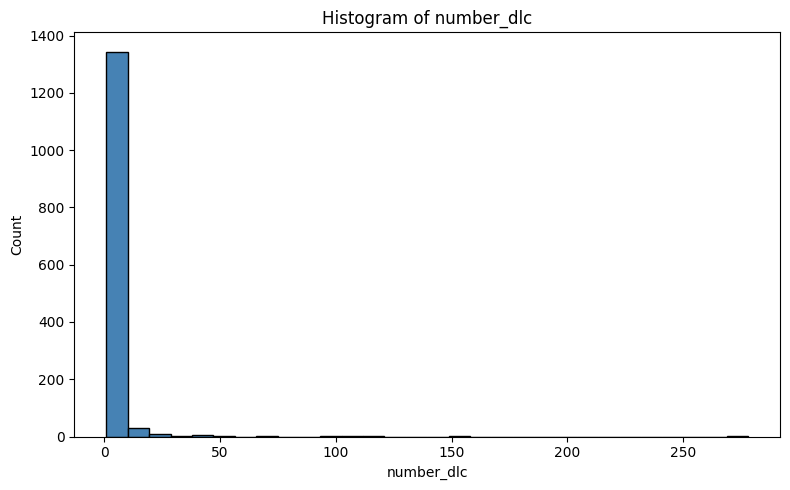

In [3]:
na_count = df["number_dlc"].isna().mean() * 100
print(f"Number of missing (NaN) values in 'number_dlc': {na_count:.2f}%")

values = df["number_dlc"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(values, bins=30, color='steelblue', edgecolor='black')
plt.title(f'Histogram of number_dlc')
plt.xlabel("number_dlc")
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# developpers and publishers

In [4]:
na_count = df["developers"].isna().mean() * 100
print(f"Number of missing (NaN) values in 'developers': {na_count:.2f}%")

na_count = df["publishers"].isna().mean() * 100
print(f"Number of missing (NaN) values in 'publishers': {na_count:.2f}%")

Number of missing (NaN) values in 'developers': 3.67%
Number of missing (NaN) values in 'publishers': 4.10%


# price_initial and price_final

Number of missing (NaN) values in 'price_initial': 31.32%
Number of missing (NaN) values in 'price_final': 31.32%


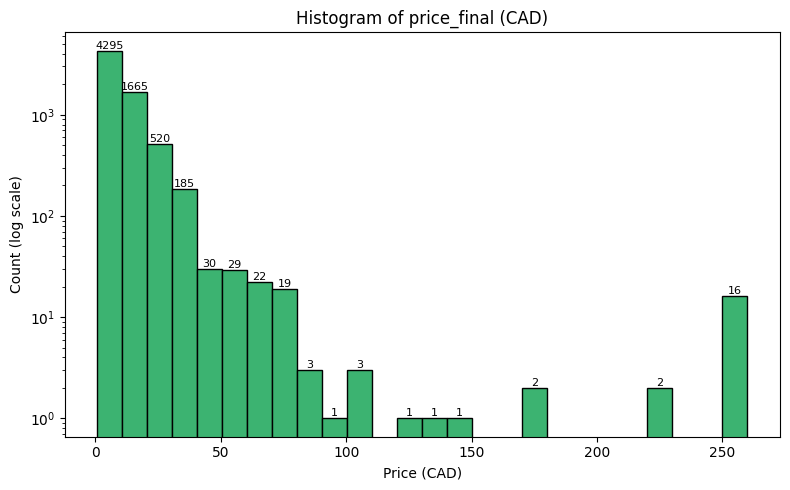

In [5]:
na_count = df["price_initial"].isna().mean() * 100
print(f"Number of missing (NaN) values in 'price_initial': {na_count:.2f}%")

na_count = df["price_final"].isna().mean() * 100
print(f"Number of missing (NaN) values in 'price_final': {na_count:.2f}%")

# Filter rows where price_currency is 'CAD'
df_cad = df[df['price_currency'] == 'CAD']

# Convert 'price_final' to numeric, drop NaNs
prices_cad = pd.to_numeric(df_cad['price_final'], errors='coerce').dropna()

# Plot histogram
fig, ax = plt.subplots(figsize=(8, 5))
counts, bins, patches = ax.hist(prices_cad, bins=26, color='mediumseagreen', edgecolor='black')

# Set y-axis to log scale
ax.set_yscale('log')

# Add counts on top of bars
for count, patch in zip(counts, patches):
    if count > 0:
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width() / 2, height,
                f'{int(count)}', ha='center', va='bottom', fontsize=8)

ax.set_title('Histogram of price_final (CAD)')
ax.set_xlabel('Price (CAD)')
ax.set_ylabel('Count (log scale)')
plt.tight_layout()
plt.show()

# windows, mac and linux

Number of missing (NaN) values in 'windows': 0.00%
Number of missing (NaN) values in 'mac': 0.00%
Number of missing (NaN) values in 'linux': 0.00%


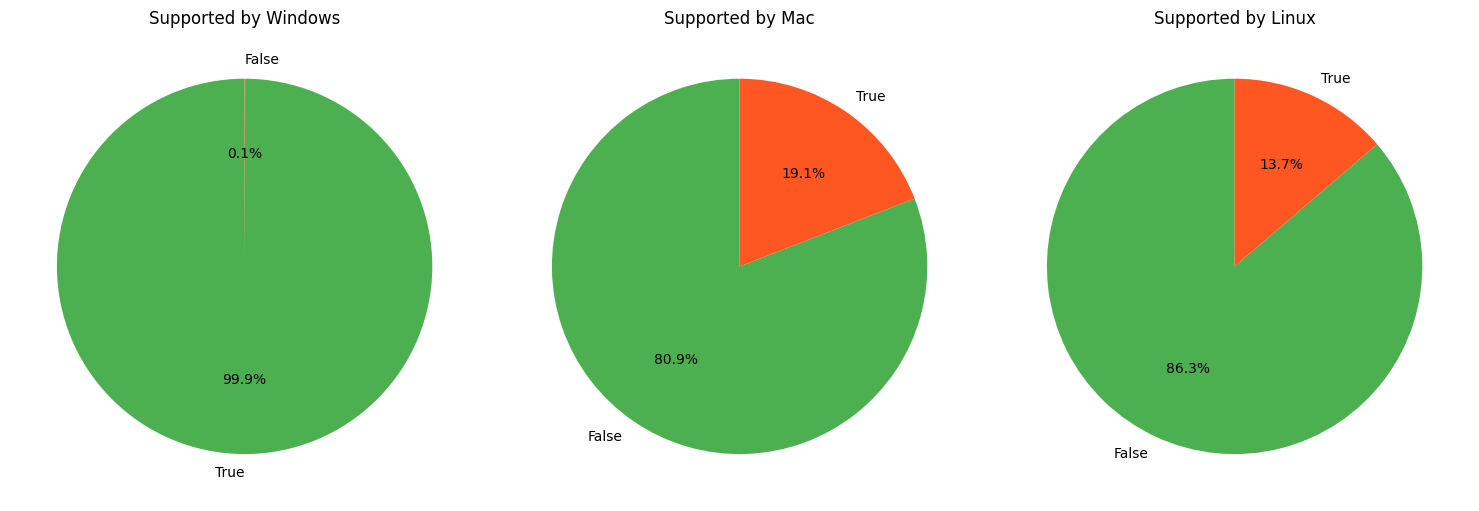

In [6]:
na_count = df["windows"].isna().mean() * 100
print(f"Number of missing (NaN) values in 'windows': {na_count:.2f}%")

na_count = df["mac"].isna().mean() * 100
print(f"Number of missing (NaN) values in 'mac': {na_count:.2f}%")

na_count = df["linux"].isna().mean() * 100
print(f"Number of missing (NaN) values in 'linux': {na_count:.2f}%")

# List of boolean columns
bool_cols = ['windows', 'mac', 'linux']

# Plot pie charts, one per column
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, bool_cols):
    counts = df[col].value_counts(dropna=False)  # counts of True and False (and NaN if any)
    # For nicer labels, convert True/False to strings
    labels = ['True' if val else 'False' for val in counts.index]
    ax.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FF5722'])
    ax.set_title(f'Supported by {col.capitalize()}')

plt.tight_layout()
plt.show()

# categories

Number of missing (NaN) values in categories: 4.08%


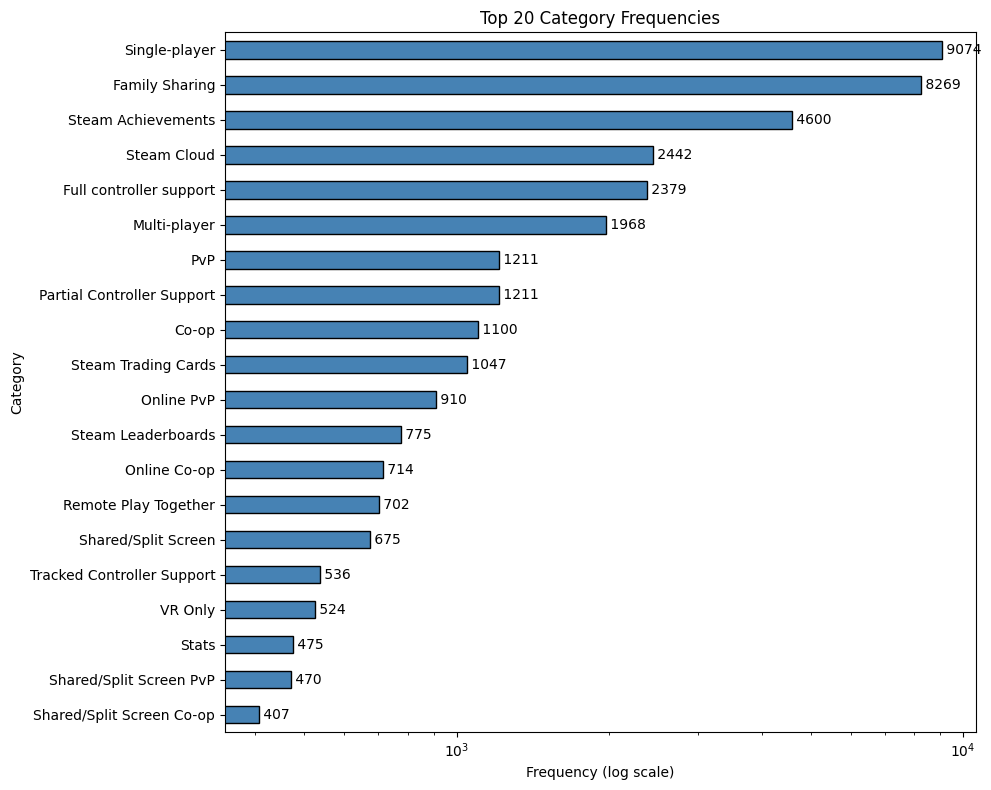

In [7]:
na_count = df["categories"].isna().mean() * 100
print(f"Number of missing (NaN) values in categories: {na_count:.2f}%")

# Column containing semicolon-separated categories
col = 'categories'

# Split, explode, strip whitespace
all_categories = df[col].dropna().str.split(';').explode().str.strip()

# Count frequencies
category_counts = all_categories.value_counts()

# Select top 20 and sort ascending for better horizontal bar order
top20 = category_counts.head(20).sort_values()

plt.figure(figsize=(10, 8))
ax = top20.plot(kind='barh', color='steelblue', edgecolor='black', logx=True)

plt.title('Top 20 Category Frequencies')
plt.xlabel('Frequency (log scale)')
plt.ylabel('Category')

# Add counts at the end of bars
for i, (count) in enumerate(top20):
    ax.text(count, i, f' {count}', va='center')

plt.tight_layout()
plt.show()

# genres

Number of missing (NaN) values in genres: 3.58%


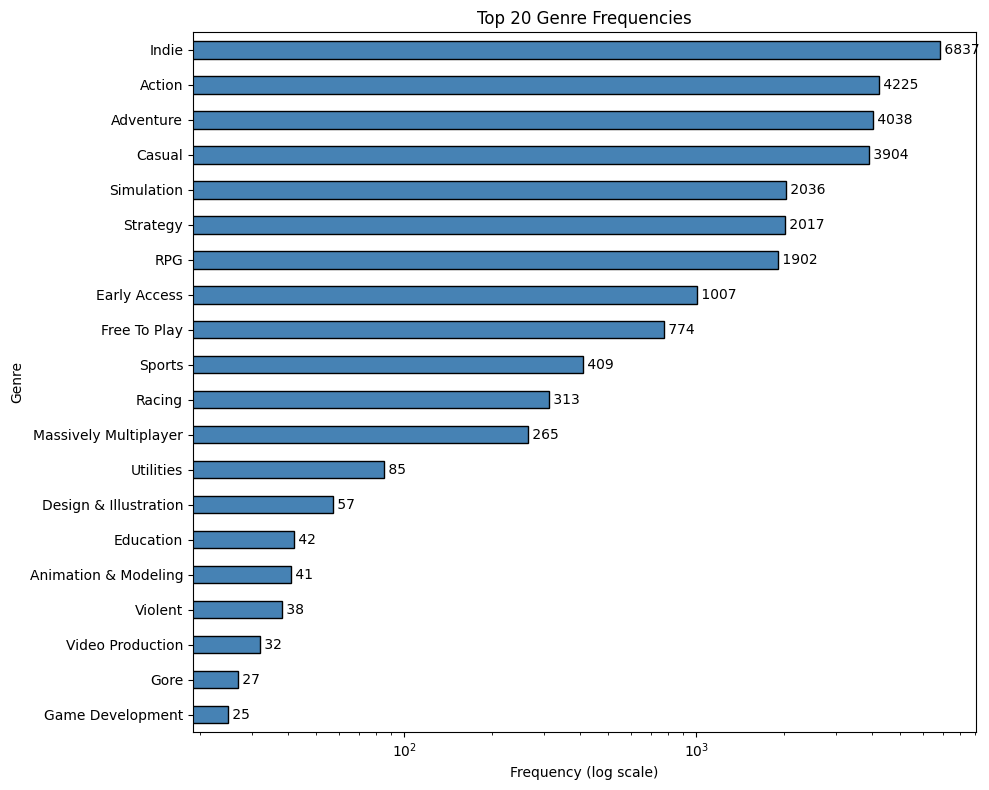

In [8]:
na_count = df["genres"].isna().mean() * 100
print(f"Number of missing (NaN) values in genres: {na_count:.2f}%")

col = 'genres'

# Split, explode, strip whitespace
all_categories = df[col].dropna().str.split(';').explode().str.strip()

# Count frequencies
category_counts = all_categories.value_counts()

# Select top 20 and sort ascending for better horizontal bar order
top20 = category_counts.head(20).sort_values()

plt.figure(figsize=(10, 8))
ax = top20.plot(kind='barh', color='steelblue', edgecolor='black', logx=True)

plt.title('Top 20 Genre Frequencies')
plt.xlabel('Frequency (log scale)')
plt.ylabel('Genre')

# Add counts at the end of bars
for i, (count) in enumerate(top20):
    ax.text(count, i, f' {count}', va='center')

plt.tight_layout()
plt.show()

# recommendations_total

Number of missing (NaN) values in recommendations_total: 83.28%


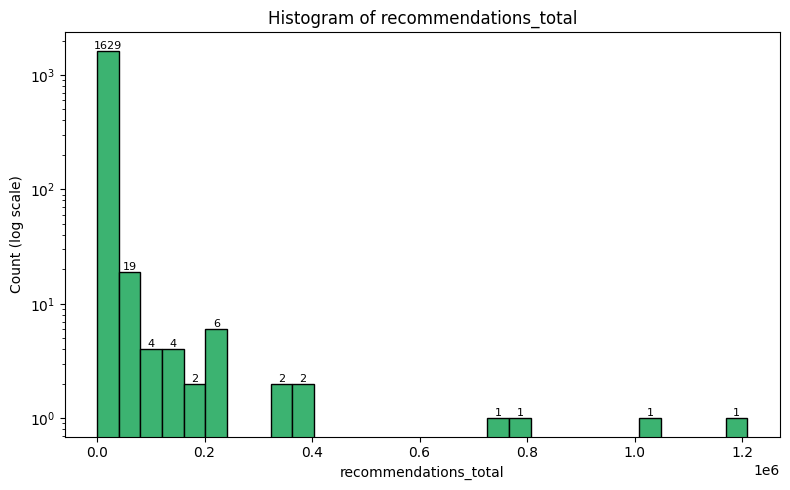

In [9]:
na_count = df["recommendations_total"].isna().mean() * 100
print(f"Number of missing (NaN) values in recommendations_total: {na_count:.2f}%")

col = 'recommendations_total'

# Convert to numeric, coerce errors to NaN, then drop NaNs
recs = pd.to_numeric(df[col], errors='coerce').dropna()

fig, ax = plt.subplots(figsize=(8, 5))

counts, bins, patches = ax.hist(recs, bins=30, color='mediumseagreen', edgecolor='black')

# Set log scale on y-axis
ax.set_yscale('log')

# Add count labels on bars
for count, patch in zip(counts, patches):
    if count > 0:
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width() / 2, height, f'{int(count)}',
                ha='center', va='bottom', fontsize=8)

ax.set_title('Histogram of recommendations_total')
ax.set_xlabel('recommendations_total')
ax.set_ylabel('Count (log scale)')

plt.tight_layout()
plt.show()

# achievements_total

Number of missing (NaN) values in achievements_total: 53.91%


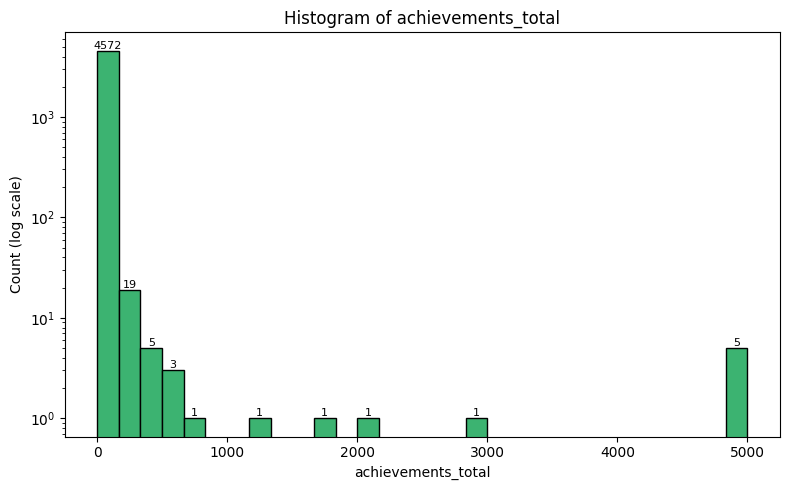

In [10]:
na_count = df["achievements_total"].isna().mean() * 100
print(f"Number of missing (NaN) values in achievements_total: {na_count:.2f}%")

col = 'achievements_total'

# Convert to numeric, coerce errors to NaN, then drop NaNs
recs = pd.to_numeric(df[col], errors='coerce').dropna()

fig, ax = plt.subplots(figsize=(8, 5))

counts, bins, patches = ax.hist(recs, bins=30, color='mediumseagreen', edgecolor='black')

# Set log scale on y-axis
ax.set_yscale('log')

# Add count labels on bars
for count, patch in zip(counts, patches):
    if count > 0:
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width() / 2, height, f'{int(count)}',
                ha='center', va='bottom', fontsize=8)

ax.set_title('Histogram of achievements_total')
ax.set_xlabel('achievements_total')
ax.set_ylabel('Count (log scale)')

plt.tight_layout()
plt.show()

# release_date

Number of missing (NaN) values in release_date: 0.31%
Percentage of cells without a valid 4-digit year: 13.90%


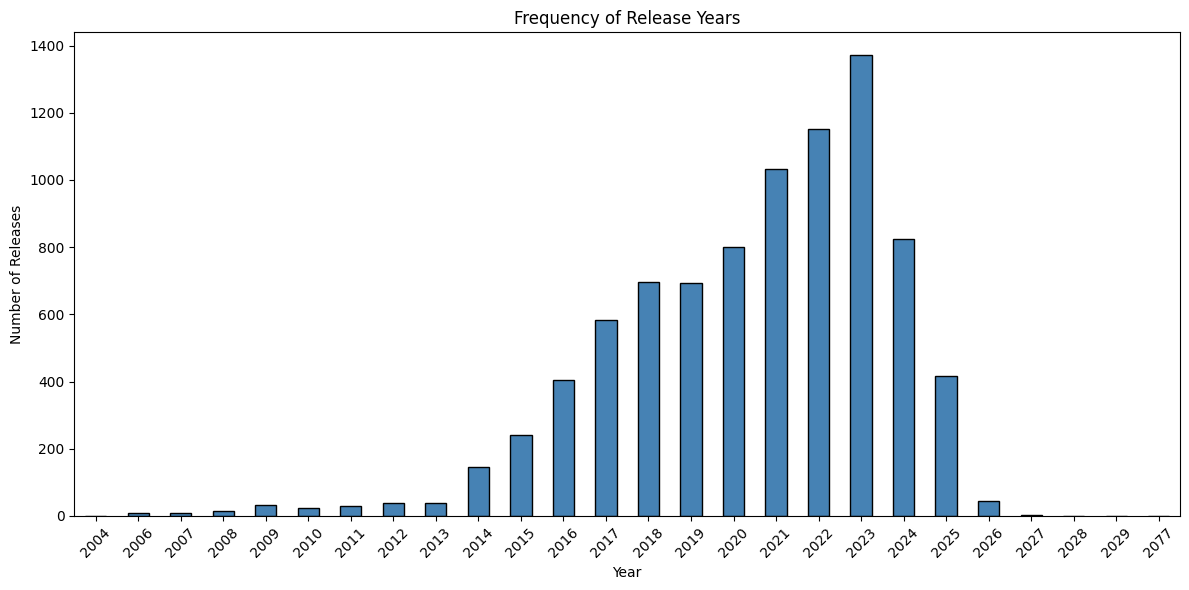

In [11]:
import re

na_count = df["release_date"].isna().mean() * 100
print(f"Number of missing (NaN) values in release_date: {na_count:.2f}%")

col = 'release_date'

# Function to check if a 4-digit year exists
def has_year(date_str):
    if pd.isna(date_str):
        return False
    return bool(re.search(r'\b\d{4}\b', date_str))

# Apply the check on the column
matches = df[col].apply(has_year)

# Calculate percentage of cells without a valid year
no_year_percentage = 100 * (1 - matches.sum() / len(matches))

print(f"Percentage of cells without a valid 4-digit year: {no_year_percentage:.2f}%")



# Function to extract 4-digit year using regex, returns None if not found
def extract_year(date_str):
    if pd.isna(date_str):
        return None
    match = re.search(r'\b(\d{4})\b', date_str)
    return match.group(1) if match else None

# Apply extraction
df['year'] = df[col].apply(extract_year)

# Drop rows where year is None
years = df['year'].dropna()

# Count frequency of each year
year_counts = years.value_counts().sort_index()

# Plot frequency of years
plt.figure(figsize=(12, 6))
year_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Frequency of Release Years')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()